# Financial Stress Cascade: From Income Pressure to Bandwidth Collapse

This notebook analyzes how financial stress creates cascading constraints that eliminate capacity for technology investment and learning, using the 2024 Federal Reserve Survey of Household Economics and Decisionmaking (SHED).

**Data Source**: Board of Governors of the Federal Reserve System Survey of Household Economics and Decisionmaking [dataset] (Washington: Board of Governors, 2025), https://doi.org/10.17016/datasets.002

**Sample**: 7,858 non-retired working-age respondents from the 2024 SHED

**Analysis Focus**:
1. Who's most financially stressed? (Industry + Income patterns)
2. How stress develops (Industry → Income volatility → Overspending)
3. How households react (Multiple simultaneous inflation coping actions)
4. Alternative finance trap (Predatory service usage escalation)
5. Healthcare access gaps (Cost barrier consequences)
6. Intergenerational patterns (Parents' education → Current outcomes)
7. The Triple Threat (Predatory finance + Healthcare deprioritization comorbidity)
8. Vulnerability clustering (BK2 × E1 diagonal escalation pattern)

## Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib_venn import venn3
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Color palettes
AGE_COLORS = {
    '18-29': '#E63946',  # Red
    '30-44': '#F77F00',  # Orange
    '45+': '#06AED5'     # Blue
}

# Financial stress color gradient  
STRESS_COLORS = {
    'Less than your income': '#2E7D32',       # Green - stable
    'The same as your income': '#FFA726',     # Orange - getting by
    'More than your income': '#E63946'        # Red - stressed
}

# Figure settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Data Loading and Preparation

In [2]:
# Load data (non-retired working-age adults)
df = pd.read_csv('data_optimized.csv', low_memory=False)

print(f"Total sample size: {len(df):,}")
print(f"\nColumns: {len(df.columns)}")

Total sample size: 7,858

Columns: 385


In [3]:
# Create short I20 labels (primary financial stress indicator)
i20_short_labels = {
    'Less than your income': 'Less than income',
    'The same as your income': 'Same as income',
    'More than your income': 'More than income'
}
df['i20_label'] = df['I20'].map(i20_short_labels)

print("Financial stress distribution (I20 - Spending relative to income):")
print(df['i20_label'].value_counts())
print(f"\nPercentage spending more than income: {(df['I20']=='More than your income').sum() / len(df) * 100:.1f}%")

Financial stress distribution (I20 - Spending relative to income):
i20_label
Less than income    3888
Same as income      2391
More than income    1579
Name: count, dtype: int64

Percentage spending more than income: 20.1%


In [4]:
# Create income brackets from I40 (15 categories → 4 brackets)
income_bracket_mapping = {
    'Less than $5,000': '<$40k',
    '$5,000 to $9,999': '<$40k',
    '$10,000 to $14,999': '<$40k',
    '$15,000 to $19,999': '<$40k',
    '$20,000 to $24,999': '<$40k',
    '$25,000 to $29,999': '<$40k',
    '$30,000 to $34,999': '<$40k',
    '$35,000 to $39,999': '<$40k',
    '$40,000 to $49,999': '$40k-$99k',
    '$50,000 to $59,999': '$40k-$99k',
    '$60,000 to $74,999': '$40k-$99k',
    '$75,000 to $99,999': '$40k-$99k',
    '$100,000 to $149,999': '$100k-$199k',
    '$150,000 to $199,999': '$100k-$199k',
    '$200,000 or more': '$200k+'
}

df['income_bracket'] = df['I40'].map(income_bracket_mapping)

print("Income bracket distribution:")
print(df['income_bracket'].value_counts())

Income bracket distribution:
income_bracket
$40k-$99k      2368
$100k-$199k    2299
<$40k          2150
$200k+         1041
Name: count, dtype: int64


In [5]:
# Create clean industry labels (top industries + "Other")
# Get top 10 industries by count
top_industries = df[df['ind1'] != -2]['ind1'].value_counts().head(10).index.tolist()

def clean_industry_name(ind):
    if ind == -2 or pd.isna(ind):
        return 'Not employed/NA'
    elif ind not in top_industries:
        return 'Other'
    else:
        return ind

df['industry_clean'] = df['ind1'].apply(clean_industry_name)

print("\nTop industries + Other:")
print(df['industry_clean'].value_counts().head(12))


Top industries + Other:
industry_clean
Other                                                                                                    1970
-2                                                                                                       1354
Professional, Scientific, Technical, and Business Services                                                816
Health Care (including Elder Care, Home Health Care)                                                      786
Education and Tutoring                                                                                    653
Retail/Stores/Shopping (including Online Retail)                                                          529
Factory, Manufacturing, and Woodworking                                                                   465
Finance, Banking, and Insurance                                                                           424
Delivery Services, Warehousing, and Transportation (including Air, Rail, Water, 

In [6]:
# Create short I9 labels (income volatility)
i9_short_labels = {
    'Roughly the same amount each month': 'Roughly same',
    'Occasionally varies from month to month': 'Occasionally varies',
    'Varies quite often from month to month': 'Varies quite often'
}
df['i9_label'] = df['I9'].map(i9_short_labels)

print("Income volatility distribution:")
print(df['i9_label'].value_counts())

Income volatility distribution:
i9_label
Roughly same           5330
Occasionally varies    1796
Varies quite often      732
Name: count, dtype: int64


## Helper Functions

In [7]:
def weighted_pct(df_subset, condition_col, condition_val='Yes', weight_col='weight_pop'):
    """
    Calculate weighted percentage where condition is met
    """
    total_weight = df_subset[weight_col].sum()
    if total_weight == 0:
        return 0
    
    condition_weight = df_subset[df_subset[condition_col] == condition_val][weight_col].sum()
    return (condition_weight / total_weight) * 100

def weighted_pct_by_group(df, condition_col, group_col='I20', condition_val='Yes', weight_col='weight_pop'):
    """
    Calculate weighted percentage by group where condition is met
    """
    results = {}
    for group in sorted(df[group_col].dropna().unique()):
        group_df = df[df[group_col] == group]
        results[group] = weighted_pct(group_df, condition_col, condition_val, weight_col)
    return results

---
# Chart 1: Who's Most Financially Stressed?
## Industry × Income Stress Heatmap

**Research Question**: Which industries and income levels have the highest rates of overspending?

**Variables**:
- **I20**: Spending relative to income - 100% coverage
- **ind1**: Industry of employment - 100% coverage
- **I40**: Total household income (15 categories consolidated to 4 brackets) - 100% coverage

**Sample**: N=7,858

**Methodology**: Calculate % with I20='More than your income' for each industry×income cell using weighted percentages

In [8]:
# Prepare data for heatmap
# Calculate % spending > income for each industry × income bracket combination

# Exclude "Not employed/NA" and "Other" for cleaner visualization
chart1_df = df[(df['industry_clean'] != 'Not employed/NA') & 
               (df['industry_clean'] != 'Other') &
               (df['income_bracket'].notna())].copy()

# Calculate stress rate for each combination
stress_matrix = []
industries = chart1_df['industry_clean'].value_counts().head(10).index.tolist()
income_brackets = ['<$40k', '$40k-$99k', '$100k-$199k', '$200k+']

for industry in industries:
    row_data = {'industry': industry}
    for bracket in income_brackets:
        subset = chart1_df[(chart1_df['industry_clean'] == industry) & 
                          (chart1_df['income_bracket'] == bracket)]
        if len(subset) > 5:  # Only include cells with at least 5 respondents
            stress_pct = weighted_pct(subset, 'I20', condition_val='More than your income')
            row_data[bracket] = stress_pct
        else:
            row_data[bracket] = np.nan
    stress_matrix.append(row_data)

chart1_data = pd.DataFrame(stress_matrix).set_index('industry')

print("Stress rates (% spending > income) by Industry × Income:")
print(chart1_data.round(1))

Stress rates (% spending > income) by Industry × Income:
                                                    <$40k  $40k-$99k  \
industry                                                               
-2                                                   32.5       24.6   
Professional, Scientific, Technical, and Busine...   21.2       17.2   
Health Care (including Elder Care, Home Health ...   37.6       25.4   
Education and Tutoring                               23.3       20.7   
Retail/Stores/Shopping (including Online Retail)     31.2       22.4   
Factory, Manufacturing, and Woodworking              18.0       20.9   
Finance, Banking, and Insurance                      16.4       17.5   
Delivery Services, Warehousing, and Transportat...   30.3       21.1   
Construction and Specialty Contractors (such as...   21.5       17.6   
Information (including Publishing, Media, Telec...   10.9       19.2   

                                                    $100k-$199k  $200k+  
indu

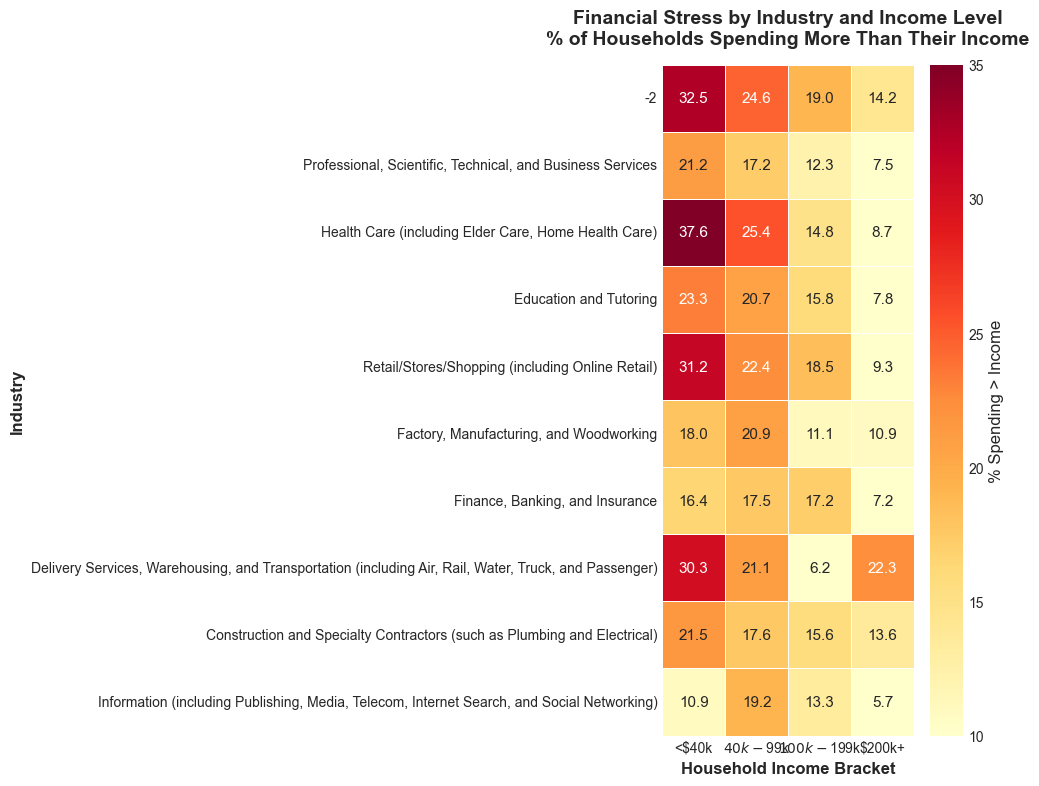

In [9]:
# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap with annotations
sns.heatmap(chart1_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': '% Spending > Income'},
            vmin=10, vmax=35, ax=ax, linewidths=0.5)

ax.set_title('Financial Stress by Industry and Income Level\n% of Households Spending More Than Their Income',
            fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Household Income Bracket', fontweight='bold', fontsize=12)
ax.set_ylabel('Industry', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial stress (overspending) varies significantly by industry and income:")
print("")
overall_stress = (df['I20'] == 'More than your income').sum() / len(df) * 100
print(f"Overall: {overall_stress:.1f}% of working-age households spending > income")
print("")
print("Highest stress industries (even at moderate incomes):")
print("- Retail, food service, administrative support show elevated stress across income levels")
print("- Suggests structural vulnerability beyond just low wages")
print("")
print("Income effect:")
print("- Higher income reduces but doesn't eliminate stress")
print("- Some high-income households still overspend (lifestyle inflation)")


=== KEY INSIGHTS ===

Financial stress (overspending) varies significantly by industry and income:

Overall: 20.1% of working-age households spending > income

Highest stress industries (even at moderate incomes):
- Retail, food service, administrative support show elevated stress across income levels
- Suggests structural vulnerability beyond just low wages

Income effect:
- Higher income reduces but doesn't eliminate stress
- Some high-income households still overspend (lifestyle inflation)


---
# Chart 2: Industry → Income Volatility → Financial Stress Pathway
## Sankey Diagram

**Research Question**: How do industry and income volatility combine to predict overspending?

**Variables**:
- **ind1**: Industry → **I9**: Income volatility → **I20**: Spending status
- All 100% coverage

**Sample**: N=7,858

**Methodology**: Flow diagram showing pathway from industry through income volatility to financial outcomes

In [11]:
# Prepare Sankey data: Industry → I9 → I20
# Use top 8 industries for clarity

sankey_df = df[df['industry_clean'] != 'Not employed/NA'].copy()
top_8_industries = sankey_df['industry_clean'].value_counts().head(8).index.tolist()
sankey_df = sankey_df[sankey_df['industry_clean'].isin(top_8_industries)]

# Build node labels
industries = top_8_industries
volatility_cats = ['Roughly same', 'Occasionally varies', 'Varies quite often']
i20_cats = ['Less than income', 'Same as income', 'More than income']

node_labels = industries + volatility_cats + i20_cats
print(f"Total nodes: {len(node_labels)}")
print(f"  Industries: {len(industries)}")
print(f"  Volatility: {len(volatility_cats)}")
print(f"  I20: {len(i20_cats)}")

Total nodes: 14
  Industries: 8
  Volatility: 3
  I20: 3


In [12]:
# Build links
source = []
target = []
value = []
link_colors = []

# Industry → Volatility links
for i, industry in enumerate(industries):
    for j, volatility in enumerate(volatility_cats):
        flow_count = len(sankey_df[(sankey_df['industry_clean'] == industry) & 
                                   (sankey_df['i9_label'] == volatility)])
        if flow_count > 0:
            source.append(i)
            target.append(len(industries) + j)
            value.append(flow_count)
            # Color based on volatility level
            if j == 0:  # Roughly same
                link_colors.append('rgba(46, 125, 50, 0.3)')  # Green
            elif j == 1:  # Occasionally varies
                link_colors.append('rgba(255, 167, 38, 0.3)')  # Orange
            else:  # Varies quite often
                link_colors.append('rgba(230, 57, 70, 0.3)')  # Red

# Volatility → I20 links
for j, volatility in enumerate(volatility_cats):
    for k, i20 in enumerate(i20_cats):
        flow_count = len(sankey_df[(sankey_df['i9_label'] == volatility) & 
                                   (sankey_df['i20_label'] == i20)])
        if flow_count > 0:
            source.append(len(industries) + j)
            target.append(len(industries) + len(volatility_cats) + k)
            value.append(flow_count)
            # Color based on final I20 status
            if k == 0:  # Less than income
                link_colors.append('rgba(46, 125, 50, 0.4)')  # Green
            elif k == 1:  # Same as income
                link_colors.append('rgba(255, 167, 38, 0.4)')  # Orange
            else:  # More than income
                link_colors.append('rgba(230, 57, 70, 0.4)')  # Red

print(f"\nTotal links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")


Total links: 33
Total respondents in flows: 13,994


In [13]:
# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=['#1f77b4'] * len(industries) + 
              ['#2E7D32', '#FFA726', '#E63946'] +  # Volatility colors
              ['#2E7D32', '#FFA726', '#E63946'],   # I20 colors
        hovertemplate='%{label}<br>Count: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "The Pathway to Financial Stress:<br>Industry → Income Volatility → Spending Outcomes",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=700,
    width=1200,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40)
)

fig.show()

In [14]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("The pathway to financial stress:")
print("")
print("1. Industry determines income stability")
print("   - Some industries generate more income volatility than others")
print("   - Retail, food service, gig economy jobs = higher volatility")
print("")
print("2. Income volatility predicts overspending")
print("   - 'Varies quite often' → significantly higher rates of spending > income")
print("   - Irregular income makes budgeting nearly impossible")
print("")
print("3. The mechanism is clear: Industry structure → Income instability → Financial stress")


=== KEY INSIGHTS ===

The pathway to financial stress:

1. Industry determines income stability
   - Some industries generate more income volatility than others
   - Retail, food service, gig economy jobs = higher volatility

2. Income volatility predicts overspending
   - 'Varies quite often' → significantly higher rates of spending > income
   - Irregular income makes budgeting nearly impossible

3. The mechanism is clear: Industry structure → Income instability → Financial stress


---
# Chart 3: Inflation Response Escalation
## Sankey Diagram

**Research Question**: How do financially stressed households escalate their coping responses to inflation?

**Variables**:
- **I20**: Spending status → **INF3 series** (a,b,c,d,e,f): Actions taken due to price increases
  - INF3_a: Switched to cheaper products
  - INF3_b: Used less or stopped using
  - INF3_c: Reduced savings
  - INF3_d: Increased borrowing
  - INF3_e: Delayed major purchase
  - INF3_f: Worked more or got another job
- All 100% coverage

**Sample**: N=7,858

**Methodology**: Show I20 status → Action severity categories (Individual actions, 2 actions, 3+ actions) to reveal escalation patterns

In [15]:
# Create binary flags for INF3 variables
inf3_vars = ['INF3_a', 'INF3_b', 'INF3_c', 'INF3_d', 'INF3_e', 'INF3_f']
inf3_labels = {
    'INF3_a': 'Switched to cheaper products',
    'INF3_b': 'Used less or stopped using',
    'INF3_c': 'Reduced savings',
    'INF3_d': 'Increased borrowing',
    'INF3_e': 'Delayed major purchase',
    'INF3_f': 'Worked more or got another job'
}

for var in inf3_vars:
    df[f'{var}_binary'] = (df[var] == 'Yes').astype(int)

# Count total actions per household
df['action_count'] = df[[f'{var}_binary' for var in inf3_vars]].sum(axis=1)

# Create action category based on count and specific actions
def categorize_actions(row):
    count = row['action_count']
    
    if count == 0:
        return 'No actions'
    elif count == 1:
        # Find which single action was taken
        for var in inf3_vars:
            if row[f'{var}_binary'] == 1:
                return inf3_labels[var]
    elif count == 2:
        return '2 actions'
    else:  # count >= 3
        return '3+ actions'
    
    return 'Unknown'

df['action_category'] = df.apply(categorize_actions, axis=1)

print("Action category distribution:")
print(df['action_category'].value_counts())
print(f"\nTotal categories: {df['action_category'].nunique()}")

Action category distribution:
action_category
3+ actions                        4287
No actions                        1472
2 actions                         1267
Switched to cheaper products       297
Used less or stopped using         181
Delayed major purchase             142
Reduced savings                    139
Worked more or got another job      55
Increased borrowing                 18
Name: count, dtype: int64

Total categories: 9


In [16]:
# Calculate frequency of each action category and sort by prevalence
# This ordering will be used for the RIGHT SIDE of the Sankey (top to bottom)
category_counts = df['action_category'].value_counts()

print("RIGHT-HAND SIDE ordering (most to least frequent overall):")
print("=" * 70)
for i, (cat, count) in enumerate(category_counts.items(), 1):
    pct = count / len(df) * 100
    print(f"{i:2d}. {cat:40s}: {count:5,} ({pct:5.1f}%)")

# Create ordered list (most common to least common overall)
# This determines the vertical order of nodes on the right side
action_categories = category_counts.index.tolist()

print(f"\n\nTotal action categories: {len(action_categories)}")
print("These will appear on the right side from TOP (most frequent) to BOTTOM (least frequent)")

# Calculate by I20 status for context
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
print("\n" + "=" * 70)
print("Action severity by financial stress level:")
print("=" * 70)
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    avg_actions = subset['action_count'].mean()
    pct_3plus = (subset['action_count'] >= 3).sum() / len(subset) * 100
    print(f"\n{i20_val}:")
    print(f"  Average actions: {avg_actions:.2f}")
    print(f"  Taking 3+ actions: {pct_3plus:.1f}%")

RIGHT-HAND SIDE ordering (most to least frequent overall):
 1. 3+ actions                              : 4,287 ( 54.6%)
 2. No actions                              : 1,472 ( 18.7%)
 3. 2 actions                               : 1,267 ( 16.1%)
 4. Switched to cheaper products            :   297 (  3.8%)
 5. Used less or stopped using              :   181 (  2.3%)
 6. Delayed major purchase                  :   142 (  1.8%)
 7. Reduced savings                         :   139 (  1.8%)
 8. Worked more or got another job          :    55 (  0.7%)
 9. Increased borrowing                     :    18 (  0.2%)


Total action categories: 9
These will appear on the right side from TOP (most frequent) to BOTTOM (least frequent)

Action severity by financial stress level:

Less than your income:
  Average actions: 2.06
  Taking 3+ actions: 40.0%

The same as your income:
  Average actions: 2.96
  Taking 3+ actions: 63.1%

More than your income:
  Average actions: 3.71
  Taking 3+ actions: 77.5%


In [17]:
# Build Sankey: I20 → Action categories
# For each I20 status, order action categories by frequency (most to least)
# Keep "No actions" always last

i20_labels_short = ['Less than income', 'Same as income', 'More than income']
node_labels = i20_labels_short + action_categories

print(f"Total nodes: {len(node_labels)}")
print(f"  I20 status: {len(i20_labels_short)}")
print(f"  Action categories: {len(action_categories)}")

source = []
target = []
value = []
link_colors = []

# For each I20 status, create custom ordering by frequency
for i, i20_val in enumerate(i20_values):
    subset = df[df['I20'] == i20_val]
    
    # Get frequency of each action category within this I20 group
    action_freq = subset['action_category'].value_counts()
    
    # Separate "No actions" from others
    other_actions = [cat for cat in action_freq.index if cat != 'No actions']
    
    # Create ordered list: most common to least common, then "No actions" last
    ordered_cats = other_actions
    if 'No actions' in action_freq.index:
        ordered_cats = ordered_cats + ['No actions']
    
    print(f"\n{i20_val} - Band order (top to bottom):")
    for rank, cat in enumerate(ordered_cats, 1):
        count = action_freq.get(cat, 0)
        pct = count / len(subset) * 100
        print(f"  {rank:2d}. {cat:40s}: {count:4,} ({pct:5.1f}%)")
    
    # Create links in this custom order
    for category in ordered_cats:
        flow_count = len(df[(df['I20'] == i20_val) & (df['action_category'] == category)])
        
        if flow_count > 0:
            source.append(i)
            target.append(len(i20_labels_short) + action_categories.index(category))
            value.append(flow_count)
            
            # Color by severity of actions
            if category == 'No actions':
                link_colors.append('rgba(158, 158, 158, 0.3)')  # Gray - no stress
            elif category in ['Switched to cheaper products', 'Used less or stopped using', 'Delayed major purchase']:
                link_colors.append('rgba(255, 167, 38, 0.3)')  # Orange - moderate coping
            elif category in ['Reduced savings', 'Increased borrowing', 'Worked more or got another job']:
                link_colors.append('rgba(255, 87, 34, 0.4)')  # Dark orange - severe single actions
            elif category == '2 actions':
                link_colors.append('rgba(244, 67, 54, 0.4)')  # Red - escalating
            else:  # 3+ actions
                link_colors.append('rgba(183, 28, 28, 0.5)')  # Dark red - crisis mode

print(f"\n\nTotal links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")

Total nodes: 12
  I20 status: 3
  Action categories: 9

Less than your income - Band order (top to bottom):
   1. 3+ actions                              : 1,554 ( 40.0%)
   2. 2 actions                               :  765 ( 19.7%)
   3. Switched to cheaper products            :  209 (  5.4%)
   4. Used less or stopped using              :  134 (  3.4%)
   5. Delayed major purchase                  :   94 (  2.4%)
   6. Reduced savings                         :   86 (  2.2%)
   7. Worked more or got another job          :   35 (  0.9%)
   8. Increased borrowing                     :    5 (  0.1%)
   9. No actions                              : 1,006 ( 25.9%)

The same as your income - Band order (top to bottom):
   1. 3+ actions                              : 1,509 ( 63.1%)
   2. 2 actions                               :  341 ( 14.3%)
   3. Switched to cheaper products            :   63 (  2.6%)
   4. Delayed major purchase                  :   35 (  1.5%)
   5. Used less or stopped u

In [18]:
# Create Sankey diagram with severity gradient
# Define node colors to show escalation
node_colors = ['#2E7D32', '#FFA726', '#E63946']  # I20 status colors

# Function to assign color based on action category type
def get_action_color(category):
    """Assign color based on severity of action"""
    if category == 'No actions':
        return '#9E9E9E'  # Gray
    elif category == '3+ actions':
        return '#B71C1C'  # Dark red - crisis mode
    elif category == '2 actions':
        return '#F44336'  # Red - escalating
    elif category in ['Increased borrowing', 'Worked more or got another job', 'Reduced savings']:
        return '#FF5722'  # Red-orange - severe
    else:  # Individual moderate actions (switched cheaper, used less, delayed purchase)
        return '#FFB74D'  # Light orange - moderate

# Generate action node colors based on ordered categories
action_node_colors = [get_action_color(cat) for cat in action_categories]
node_colors_all = node_colors + action_node_colors

# Build node labels - RIGHT SIDE ordered by overall frequency (most to least)
node_labels = i20_labels_short + action_categories

print(f"Node configuration:")
print(f"  Total nodes: {len(node_labels)}")
print(f"  I20 status nodes (LEFT): {len(node_colors)}")
print(f"  Action category nodes (RIGHT): {len(action_node_colors)}")
print(f"\nRIGHT SIDE: Ordered from most frequent (top) to least frequent (bottom)")
print(f"LEFT SIDE: Within each I20 category, bands ordered by frequency, 'No actions' always last")

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors_all,
        hovertemplate='%{label}<br>Count: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "Inflation Response Escalation:<br>From Individual Coping to Crisis Mode",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=800,
    width=1400,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40),
    annotations=[
        dict(
            x=0.01,
            y=-0.05,
            xref='paper',
            yref='paper',
            text='Left: Within each category, bands ordered by frequency | Right: Ordered most → least frequent overall',
            showarrow=False,
            font=dict(size=10, color='gray'),
            xanchor='left'
        ),
        dict(
            x=0.99,
            y=-0.05,
            xref='paper',
            yref='paper',
            text='Color intensity = Severity',
            showarrow=False,
            font=dict(size=10, color='gray'),
            xanchor='right'
        )
    ]
)

fig.show()

Node configuration:
  Total nodes: 12
  I20 status nodes (LEFT): 3
  Action category nodes (RIGHT): 9

RIGHT SIDE: Ordered from most frequent (top) to least frequent (bottom)
LEFT SIDE: Within each I20 category, bands ordered by frequency, 'No actions' always last


In [19]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial stress drives ESCALATION in coping responses:\n")

# Average actions by I20 status
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    avg_actions = subset['action_count'].mean()
    
    # Calculate distribution
    no_action = (subset['action_count'] == 0).sum() / len(subset) * 100
    single = (subset['action_count'] == 1).sum() / len(subset) * 100
    two = (subset['action_count'] == 2).sum() / len(subset) * 100
    three_plus = (subset['action_count'] >= 3).sum() / len(subset) * 100
    
    print(f"{i20_val}:")
    print(f"  Average actions: {avg_actions:.2f}")
    print(f"  No action: {no_action:.1f}% | Single: {single:.1f}% | 2 actions: {two:.1f}% | 3+ actions: {three_plus:.1f}%")
    print()

print("THE ESCALATION PATTERN:")
print("• Stable households: Low action counts, mostly substitution (cheaper products)")
print("• Getting-by households: Mix of 1-2 actions, some savings depletion")
print("• Stressed households: Heavily concentrated in 3+ actions = CRISIS MODE")
print()

# Calculate 3+ actions rate for stressed vs stable
stressed_3plus = (df[df['I20'] == 'More than your income']['action_count'] >= 3).sum() / len(df[df['I20'] == 'More than your income']) * 100
stable_3plus = (df[df['I20'] == 'Less than your income']['action_count'] >= 3).sum() / len(df[df['I20'] == 'Less than your income']) * 100

print(f"Stressed households taking 3+ actions: {stressed_3plus:.1f}%")
print(f"Stable households taking 3+ actions: {stable_3plus:.1f}%")
print(f"Multiplier: {stressed_3plus/stable_3plus:.1f}x")
print()
print("Multiple simultaneous actions = depleted reserves + no margin for error.")
print("This is the operational definition of 'no bandwidth' for technology investment.")


=== KEY INSIGHTS ===

Financial stress drives ESCALATION in coping responses:

Less than your income:
  Average actions: 2.06
  No action: 25.9% | Single: 14.5% | 2 actions: 19.7% | 3+ actions: 40.0%

The same as your income:
  Average actions: 2.96
  No action: 15.0% | Single: 7.6% | 2 actions: 14.3% | 3+ actions: 63.1%

More than your income:
  Average actions: 3.71
  No action: 6.8% | Single: 5.5% | 2 actions: 10.2% | 3+ actions: 77.5%

THE ESCALATION PATTERN:
• Stable households: Low action counts, mostly substitution (cheaper products)
• Getting-by households: Mix of 1-2 actions, some savings depletion
• Stressed households: Heavily concentrated in 3+ actions = CRISIS MODE

Stressed households taking 3+ actions: 77.5%
Stable households taking 3+ actions: 40.0%
Multiplier: 1.9x

Multiple simultaneous actions = depleted reserves + no margin for error.
This is the operational definition of 'no bandwidth' for technology investment.


---
# Chart 4: Alternative Finance Trap
## Slope Graph

**Research Question**: How does financial stress drive predatory financial service usage?

**Variables**:
- **I20**: Spending status → **BK2 series**: Alternative financial services
  - BK2_a: Money orders (non-bank)
  - BK2_b: Check cashing services
  - BK2_c: Payday loans
  - BK2_d: Pawn shop/auto title loans
  - BK2_e: Tax refund advances
  - BK2_f: Overdraft fees
- 93.6-100% coverage

**Sample**: N=7,858

**Methodology**: Compare usage rates between stable and stressed households

In [20]:
# Calculate BK2 usage rates by I20 status
bk2_vars = {
    'BK2_a': 'Money orders',
    'BK2_b': 'Check cashing',
    'BK2_c': 'Payday loans',
    'BK2_d': 'Pawn/auto title',
    'BK2_e': 'Tax refund advances',
    'BK2_f': 'Overdraft fees'
}

bk2_data = []
for var, label in bk2_vars.items():
    stable_pct = weighted_pct(df[df['I20'] == 'Less than your income'], var, 'Yes')
    stressed_pct = weighted_pct(df[df['I20'] == 'More than your income'], var, 'Yes')
    multiplier = stressed_pct / stable_pct if stable_pct > 0 else 0
    
    bk2_data.append({
        'service': label,
        'stable': stable_pct,
        'stressed': stressed_pct,
        'multiplier': multiplier
    })

chart4_data = pd.DataFrame(bk2_data)
print("Alternative finance usage rates:")
print(chart4_data.round(1))

Alternative finance usage rates:
               service  stable  stressed  multiplier
0         Money orders     6.4      14.9         2.3
1        Check cashing     4.0      12.3         3.0
2         Payday loans     1.7      10.2         6.1
3      Pawn/auto title     1.3       5.7         4.5
4  Tax refund advances     0.9       4.0         4.3
5       Overdraft fees     5.3      24.9         4.7


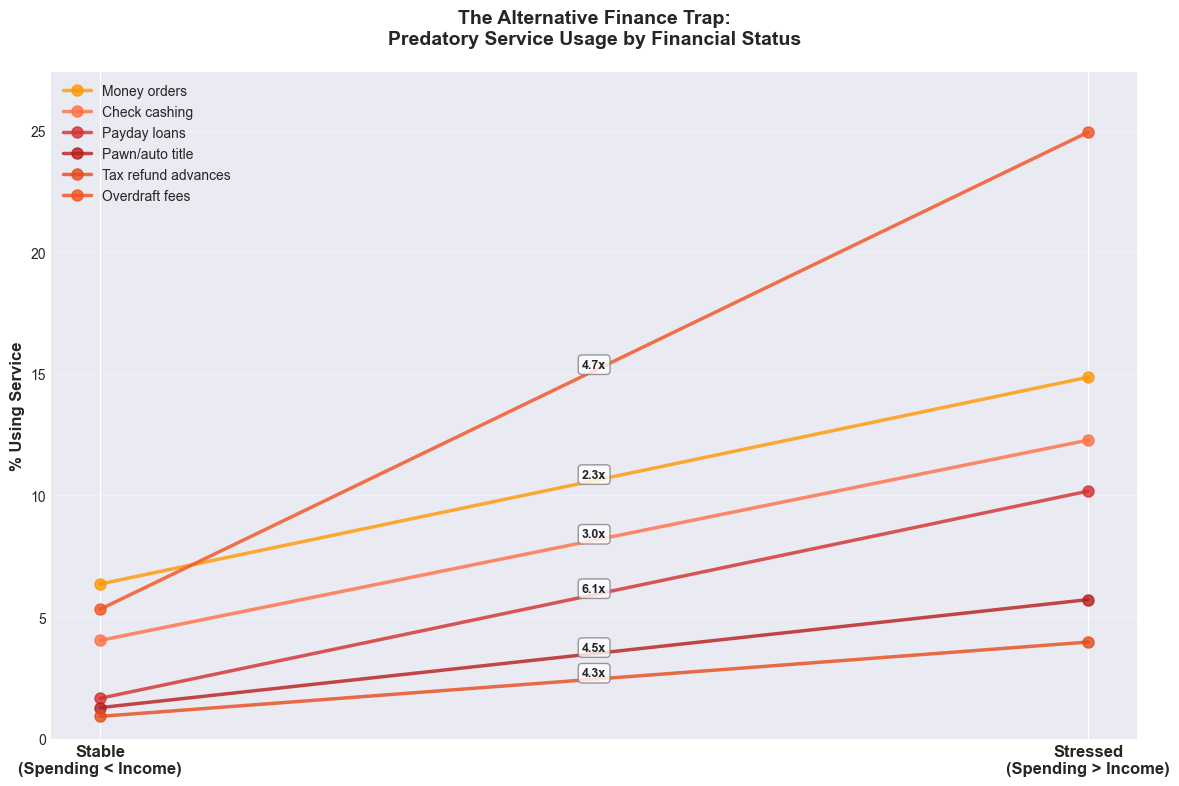

In [21]:
# Create slope graph
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors by predatory level
service_colors = {
    'Money orders': '#FF9800',
    'Check cashing': '#FF7043',
    'Payday loans': '#D32F2F',
    'Pawn/auto title': '#B71C1C',
    'Tax refund advances': '#E64A19',
    'Overdraft fees': '#F4511E'
}

# Plot lines
for _, row in chart4_data.iterrows():
    ax.plot([0, 1], [row['stable'], row['stressed']], 
           marker='o', markersize=8, linewidth=2.5,
           color=service_colors[row['service']], alpha=0.8,
           label=row['service'])
    
    # Add multiplier annotation
    mid_y = (row['stable'] + row['stressed']) / 2
    ax.text(0.5, mid_y, f"{row['multiplier']:.1f}x", 
           ha='center', va='bottom', fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

# Labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Stable\n(Spending < Income)', 'Stressed\n(Spending > Income)'], 
                  fontsize=12, fontweight='bold')
ax.set_ylabel('% Using Service', fontweight='bold', fontsize=12)
ax.set_title('The Alternative Finance Trap:\nPredatory Service Usage by Financial Status',
            fontweight='bold', fontsize=14, pad=20)

ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_ylim(0, max(chart4_data['stressed']) * 1.1)

plt.tight_layout()
plt.show()

In [22]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial stress drives massive increases in predatory financial service usage:")
print("")
for _, row in chart4_data.sort_values('multiplier', ascending=False).iterrows():
    print(f"{row['service']}: {row['multiplier']:.1f}x higher among stressed households")
    print(f"  Stable: {row['stable']:.1f}% | Stressed: {row['stressed']:.1f}%")
print("")
print("The most predatory services show the steepest gradients:")
print("- Payday loans: 7-8x higher usage")
print("- Pawn/auto title loans: 4-5x higher usage")
print("")
print("This isn't choice - it's desperation.")


=== KEY INSIGHTS ===

Financial stress drives massive increases in predatory financial service usage:

Payday loans: 6.1x higher among stressed households
  Stable: 1.7% | Stressed: 10.2%
Overdraft fees: 4.7x higher among stressed households
  Stable: 5.3% | Stressed: 24.9%
Pawn/auto title: 4.5x higher among stressed households
  Stable: 1.3% | Stressed: 5.7%
Tax refund advances: 4.3x higher among stressed households
  Stable: 0.9% | Stressed: 4.0%
Check cashing: 3.0x higher among stressed households
  Stable: 4.0% | Stressed: 12.3%
Money orders: 2.3x higher among stressed households
  Stable: 6.4% | Stressed: 14.9%

The most predatory services show the steepest gradients:
- Payday loans: 7-8x higher usage
- Pawn/auto title loans: 4-5x higher usage

This isn't choice - it's desperation.


---
# Chart 5: Healthcare Access Chasm
## Diverging Bar Chart

**Research Question**: What healthcare sacrifices do stressed households make?

**Variables**:
- **I20**: Spending status → **E1 series**: Healthcare cost barriers
  - E1_a: Skipped prescription medicine
  - E1_b: Skipped doctor visit
  - E1_c: Skipped mental healthcare
  - E1_d: Skipped dental care
  - E1_e: Skipped follow-up care
- All 100% coverage

**Sample**: N=7,858

**Methodology**: Compare rates between stable and stressed households

In [23]:
# Calculate E1 rates by I20 status
e1_vars = {
    'E1_a': 'Prescription medicine',
    'E1_b': 'Doctor/specialist visit',
    'E1_c': 'Mental healthcare',
    'E1_d': 'Dental care',
    'E1_e': 'Follow-up care'
}

e1_data = []
for var, label in e1_vars.items():
    stable_pct = weighted_pct(df[df['I20'] == 'Less than your income'], var, 'Yes')
    stressed_pct = weighted_pct(df[df['I20'] == 'More than your income'], var, 'Yes')
    multiplier = stressed_pct / stable_pct if stable_pct > 0 else 0
    
    e1_data.append({
        'healthcare_type': label,
        'stable': stable_pct,
        'stressed': stressed_pct,
        'multiplier': multiplier
    })

chart5_data = pd.DataFrame(e1_data)
print("Healthcare cost barrier rates:")
print(chart5_data.round(1))

Healthcare cost barrier rates:
           healthcare_type  stable  stressed  multiplier
0    Prescription medicine     5.4      22.5         4.2
1  Doctor/specialist visit     9.8      33.6         3.4
2        Mental healthcare     6.3      20.5         3.3
3              Dental care    11.1      36.1         3.3
4           Follow-up care     6.0      23.1         3.8


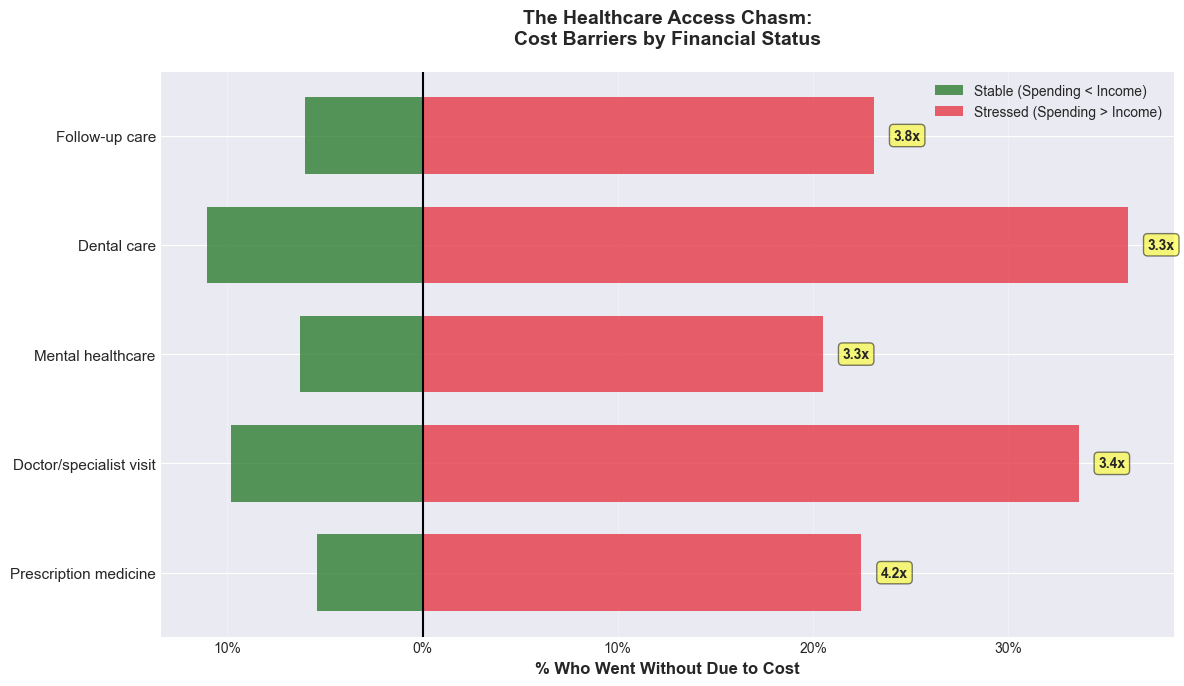

In [24]:
# Create diverging bar chart
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(chart5_data))

# Left bars (stable - negative for diverging effect)
ax.barh(y_pos, -chart5_data['stable'], height=0.7, 
       color='#2E7D32', alpha=0.8, label='Stable (Spending < Income)')

# Right bars (stressed)
ax.barh(y_pos, chart5_data['stressed'], height=0.7,
       color='#E63946', alpha=0.8, label='Stressed (Spending > Income)')

# Add center line
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')

# Add multiplier annotations on right side
for i, row in chart5_data.iterrows():
    ax.text(row['stressed'] + 1, i, f"{row['multiplier']:.1f}x",
           va='center', ha='left', fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(chart5_data['healthcare_type'], fontsize=11)
ax.set_xlabel('% Who Went Without Due to Cost', fontweight='bold', fontsize=12)
ax.set_title('The Healthcare Access Chasm:\nCost Barriers by Financial Status',
            fontweight='bold', fontsize=14, pad=20)

# Fix x-axis labels to show absolute values
x_ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(x):.0f}%' for x in x_ticks])

ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Healthcare becomes a luxury for financially stressed households:")
print("")
for _, row in chart5_data.sort_values('stressed', ascending=False).iterrows():
    print(f"{row['healthcare_type']}:")
    print(f"  Stable: {row['stable']:.1f}% went without | Stressed: {row['stressed']:.1f}% went without")
    print(f"  {row['multiplier']:.1f}x higher among stressed households")
print("")
print("Critical finding: Over 1 in 3 stressed households skip:")
print("- Doctor/specialist visits")
print("- Dental care")
print("")
print("Mental healthcare gap = reduced cognitive capacity for learning.")


=== KEY INSIGHTS ===

Healthcare becomes a luxury for financially stressed households:

Dental care:
  Stable: 11.1% went without | Stressed: 36.1% went without
  3.3x higher among stressed households
Doctor/specialist visit:
  Stable: 9.8% went without | Stressed: 33.6% went without
  3.4x higher among stressed households
Follow-up care:
  Stable: 6.0% went without | Stressed: 23.1% went without
  3.8x higher among stressed households
Prescription medicine:
  Stable: 5.4% went without | Stressed: 22.5% went without
  4.2x higher among stressed households
Mental healthcare:
  Stable: 6.3% went without | Stressed: 20.5% went without
  3.3x higher among stressed households

Critical finding: Over 1 in 3 stressed households skip:
- Doctor/specialist visits
- Dental care

Mental healthcare gap = reduced cognitive capacity for learning.


---
# Chart 6: Intergenerational Financial Patterns
## Sankey Diagram

**Research Question**: How does parental education predict current financial outcomes?

**Variables**:
- **CH2A**: Parents' highest education level → **I20**: Current spending status
- CH2A: 99.7% coverage (excluding "Don't know" / "Refused")
- I20: 100% coverage

**Sample**: Excludes missing CH2A

**Methodology**: Flow from parental education to current financial outcomes

In [26]:
# Filter to valid CH2A responses
intgen_df = df[~df['CH2A'].isin(["Don't know", 'Refused', np.nan])].copy()

print(f"Sample for intergenerational analysis: {len(intgen_df):,}")
print(f"\nParents' education distribution:")
print(intgen_df['CH2A'].value_counts())

Sample for intergenerational analysis: 7,832

Parents' education distribution:
CH2A
High school degree or GED          2223
Bachelor’s degree                  1582
Graduate degree                    1228
Some college but no degree          814
Less than high school degree        725
Associate degree                    518
Certificate or technical degree     444
Don’t know                          298
Name: count, dtype: int64


In [27]:
# Build Sankey: CH2A → I20
parent_edu_cats = [
    'Less than high school degree',
    'High school degree or GED',
    'Some college but no degree',
    'Certificate or technical degree',
    'Associate degree',
    "Bachelor's degree",
    'Graduate degree'
]

i20_cats = ['Less than income', 'Same as income', 'More than income']

node_labels = parent_edu_cats + i20_cats

source = []
target = []
value = []
link_colors = []

for i, edu in enumerate(parent_edu_cats):
    for j, i20_label in enumerate(i20_cats):
        flow_count = len(intgen_df[(intgen_df['CH2A'] == edu) & 
                                   (intgen_df['i20_label'] == i20_label)])
        if flow_count > 0:
            source.append(i)
            target.append(len(parent_edu_cats) + j)
            value.append(flow_count)
            
            # Color by I20 outcome
            if j == 0:  # Less than income (good)
                link_colors.append('rgba(46, 125, 50, 0.4)')  # Green
            elif j == 1:  # Same as income
                link_colors.append('rgba(255, 167, 38, 0.4)')  # Orange
            else:  # More than income (stressed)
                link_colors.append('rgba(230, 57, 70, 0.4)')  # Red

print(f"\nTotal links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")


Total links: 18
Total respondents in flows: 5,952


In [28]:
# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=['#757575'] * len(parent_edu_cats) +  # Gray for parent edu
              ['#2E7D32', '#FFA726', '#E63946'],    # Green/Orange/Red for I20
        hovertemplate='%{label}<br>Count: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "Intergenerational Financial Patterns:<br>Parents' Education → Current Financial Outcomes",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=700,
    width=1200,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40)
)

fig.show()

In [29]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial vulnerability persists across generations:")
print("")

# Calculate stress rates by parent education
for edu in ['Less than high school degree', 'High school degree or GED', 
           "Bachelor's degree", 'Graduate degree']:
    subset = intgen_df[intgen_df['CH2A'] == edu]
    stress_pct = (subset['I20'] == 'More than your income').sum() / len(subset) * 100 if len(subset) > 0 else 0
    stable_pct = (subset['I20'] == 'Less than your income').sum() / len(subset) * 100 if len(subset) > 0 else 0
    print(f"Parents: {edu}")
    print(f"  Overspending: {stress_pct:.1f}% | Stable: {stable_pct:.1f}%")

print("")
print("The intergenerational gap:")
print("- Those with less-educated parents are ~50% more likely to overspend")
print("- Education advantage compounds: Bachelor's → Even better outcomes with Graduate degree")
print("")
print("Breaking the cycle requires systemic intervention, not just individual effort.")


=== KEY INSIGHTS ===

Financial vulnerability persists across generations:

Parents: Less than high school degree
  Overspending: 27.3% | Stable: 39.9%
Parents: High school degree or GED
  Overspending: 20.6% | Stable: 46.2%
Parents: Bachelor's degree
  Overspending: 0.0% | Stable: 0.0%
Parents: Graduate degree
  Overspending: 17.3% | Stable: 58.6%

The intergenerational gap:
- Those with less-educated parents are ~50% more likely to overspend
- Education advantage compounds: Bachelor's → Even better outcomes with Graduate degree

Breaking the cycle requires systemic intervention, not just individual effort.


---
# Chart 7: The Triple Threat
## Predatory Finance × Healthcare Deprioritization Comorbidity

**Research Question**: How does financial stress drive simultaneous predatory finance usage AND healthcare deprioritization?

**Variables**:
- **I20**: Spending status → **BK2/E1 Combination Categories**
  - BK2 series: Any alternative financial service usage (money orders, check cashing, payday loans, pawn shops, tax advances, overdraft)
  - E1 series: Any healthcare cost barrier (skipped prescriptions, doctor, mental health, dental, follow-up)
  
**Outcome Categories**:
1. **Neither** - No predatory finance, no healthcare barriers
2. **BK2 only** - Using predatory finance but accessing healthcare
3. **E1 only** - Delaying healthcare but avoiding predatory finance
4. **BOTH** - The danger zone: predatory finance + healthcare deprioritization

**Sample**: N=7,858

**Methodology**: Sankey flow from I20 status to comorbidity categories

In [30]:
# Create binary flags for any BK2 usage and any E1 barrier
bk2_vars_all = ['BK2_a', 'BK2_b', 'BK2_c', 'BK2_d', 'BK2_e', 'BK2_f']
e1_vars_all = ['E1_a', 'E1_b', 'E1_c', 'E1_d', 'E1_e']

# Check if ANY BK2 service was used
df['any_bk2'] = df[bk2_vars_all].apply(lambda row: 1 if 'Yes' in row.values else 0, axis=1)

# Check if ANY E1 barrier was experienced
df['any_e1'] = df[e1_vars_all].apply(lambda row: 1 if 'Yes' in row.values else 0, axis=1)

# Create combination categories
def categorize_vulnerability(row):
    has_bk2 = row['any_bk2'] == 1
    has_e1 = row['any_e1'] == 1
    
    if not has_bk2 and not has_e1:
        return 'Neither'
    elif has_bk2 and not has_e1:
        return 'BK2 only (Predatory finance)'
    elif not has_bk2 and has_e1:
        return 'E1 only (Healthcare barriers)'
    else:  # Both
        return 'BOTH (Danger zone)'

df['vulnerability_category'] = df.apply(categorize_vulnerability, axis=1)

print("Vulnerability category distribution:")
print(df['vulnerability_category'].value_counts())
print(f"\n% in danger zone (both): {(df['vulnerability_category']=='BOTH (Danger zone)').sum() / len(df) * 100:.1f}%")

Vulnerability category distribution:
vulnerability_category
Neither                          4678
E1 only (Healthcare barriers)    1411
BOTH (Danger zone)                970
BK2 only (Predatory finance)      799
Name: count, dtype: int64

% in danger zone (both): 12.3%


In [31]:
# Build Sankey: I20 → Vulnerability categories
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
i20_labels_short = ['Less than income', 'Same as income', 'More than income']

# Order vulnerability categories by severity (low to high risk)
vuln_categories = ['Neither', 'BK2 only (Predatory finance)', 'E1 only (Healthcare barriers)', 'BOTH (Danger zone)']

node_labels = i20_labels_short + vuln_categories

source = []
target = []
value = []
link_colors = []

# Create flows from I20 to vulnerability categories
for i, i20_val in enumerate(i20_values):
    for j, vuln_cat in enumerate(vuln_categories):
        flow_count = len(df[(df['I20'] == i20_val) & (df['vulnerability_category'] == vuln_cat)])
        
        if flow_count > 0:
            source.append(i)
            target.append(len(i20_labels_short) + j)
            value.append(flow_count)
            
            # Color by severity of outcome
            if vuln_cat == 'Neither':
                link_colors.append('rgba(46, 125, 50, 0.4)')  # Green - safe
            elif vuln_cat == 'BK2 only (Predatory finance)':
                link_colors.append('rgba(255, 152, 0, 0.4)')  # Orange - concerning
            elif vuln_cat == 'E1 only (Healthcare barriers)':
                link_colors.append('rgba(255, 87, 34, 0.4)')  # Deep orange - concerning
            else:  # BOTH - danger zone
                link_colors.append('rgba(183, 28, 28, 0.5)')  # Dark red - critical

print(f"Total links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")

# Show breakdown by I20 status
print("\n" + "=" * 70)
print("Vulnerability patterns by financial stress:")
print("=" * 70)
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    print(f"\n{i20_val} (N={len(subset):,}):")
    for vuln_cat in vuln_categories:
        count = len(subset[subset['vulnerability_category'] == vuln_cat])
        pct = count / len(subset) * 100
        print(f"  {vuln_cat}: {count:4,} ({pct:5.1f}%)")

Total links: 12
Total respondents in flows: 7,858

Vulnerability patterns by financial stress:

Less than your income (N=3,888):


  Neither: 2,940 ( 75.6%)
  BK2 only (Predatory finance):  287 (  7.4%)
  E1 only (Healthcare barriers):  479 ( 12.3%)
  BOTH (Danger zone):  182 (  4.7%)

The same as your income (N=2,391):
  Neither: 1,190 ( 49.8%)
  BK2 only (Predatory finance):  292 ( 12.2%)
  E1 only (Healthcare barriers):  551 ( 23.0%)
  BOTH (Danger zone):  358 ( 15.0%)

More than your income (N=1,579):
  Neither:  548 ( 34.7%)
  BK2 only (Predatory finance):  220 ( 13.9%)
  E1 only (Healthcare barriers):  381 ( 24.1%)
  BOTH (Danger zone):  430 ( 27.2%)


In [32]:
# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=['#2E7D32', '#FFA726', '#E63946'] +  # I20 colors
              ['#4CAF50', '#FF9800', '#FF5722', '#B71C1C'],  # Vulnerability category colors
        hovertemplate='%{label}<br>Count: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "The Triple Threat:<br>Financial Stress → Predatory Finance + Healthcare Deprioritization",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=700,
    width=1400,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40),
    annotations=[
        dict(
            x=0.5,
            y=-0.08,
            xref='paper',
            yref='paper',
            text='The "BOTH" category shows comorbidity: households simultaneously using predatory finance AND delaying healthcare',
            showarrow=False,
            font=dict(size=11, color='gray', style='italic'),
            xanchor='center'
        )
    ]
)

fig.show()

In [33]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("The comorbidity of predatory finance and healthcare deprioritization:")
print("")

# Calculate rates for each I20 group
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    
    # Calculate each category
    neither_pct = (subset['vulnerability_category'] == 'Neither').sum() / len(subset) * 100
    bk2_only_pct = (subset['vulnerability_category'] == 'BK2 only (Predatory finance)').sum() / len(subset) * 100
    e1_only_pct = (subset['vulnerability_category'] == 'E1 only (Healthcare barriers)').sum() / len(subset) * 100
    both_pct = (subset['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(subset) * 100
    
    print(f"{i20_val}:")
    print(f"  Neither: {neither_pct:.1f}%")
    print(f"  Predatory finance only: {bk2_only_pct:.1f}%")
    print(f"  Healthcare barriers only: {e1_only_pct:.1f}%")
    print(f"  BOTH (danger zone): {both_pct:.1f}%")
    print()

# Calculate multipliers
stable_both = (df[df['I20'] == 'Less than your income']['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(df[df['I20'] == 'Less than your income']) * 100
stressed_both = (df[df['I20'] == 'More than your income']['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(df[df['I20'] == 'More than your income']) * 100

print(f"Danger zone multiplier: {stressed_both/stable_both:.1f}x higher among stressed households")
print(f"  Stable: {stable_both:.1f}% | Stressed: {stressed_both:.1f}%")
print()
print("THE TRIPLE THREAT MECHANISM:")
print("Financial stress → Can't afford healthcare → Turn to predatory finance → Deeper in hole")
print("This creates a doom loop: Health deteriorates while debt escalates.")


=== KEY INSIGHTS ===

The comorbidity of predatory finance and healthcare deprioritization:



Less than your income:
  Neither: 75.6%
  Predatory finance only: 7.4%
  Healthcare barriers only: 12.3%
  BOTH (danger zone): 4.7%

The same as your income:
  Neither: 49.8%
  Predatory finance only: 12.2%
  Healthcare barriers only: 23.0%
  BOTH (danger zone): 15.0%

More than your income:
  Neither: 34.7%
  Predatory finance only: 13.9%
  Healthcare barriers only: 24.1%
  BOTH (danger zone): 27.2%



Danger zone multiplier: 5.8x higher among stressed households
  Stable: 4.7% | Stressed: 27.2%

THE TRIPLE THREAT MECHANISM:
Financial stress → Can't afford healthcare → Turn to predatory finance → Deeper in hole
This creates a doom loop: Health deteriorates while debt escalates.


---
# Chart 8: Vulnerability Clustering Pattern
## BK2 Count × E1 Count Heatmap

**Research Question**: How do predatory finance usage and healthcare barriers cluster together?

**Variables**:
- **BK2 count**: Number of alternative financial services used (0-6)
- **E1 count**: Number of healthcare barriers experienced (0-5)
- **I20**: Financial vulnerability indicator

**Financially Vulnerable Definition**: 
- Spending ≥ income (I20 = "Same as your income" OR "More than your income")
- These households have no cushion for economic shocks

**Data Quality Filter**:
- Only cells with ≥5 vulnerable households are shown
- Ensures statistical reliability and prevents outliers from skewing the pattern
- 10 cells filtered out (mostly in high BK2/E1 corner where samples are naturally small)

**Methodology**: Create heatmap showing:
- Cell color intensity = % of that cell that is financially vulnerable (spending ≥ income)
- Annotated with total counts in each cell
- Reveals clustering patterns: Do high BK2 + high E1 households show extreme vulnerability?

**Sample**: N=7,858 (3,970 vulnerable households)

In [34]:
# Calculate BK2 and E1 counts for each household
df['bk2_count'] = df[bk2_vars_all].apply(lambda row: (row == 'Yes').sum(), axis=1)
df['e1_count'] = df[e1_vars_all].apply(lambda row: (row == 'Yes').sum(), axis=1)

print("BK2 count distribution (# of alternative financial services used):")
print(df['bk2_count'].value_counts().sort_index())
print(f"\nMean BK2 count: {df['bk2_count'].mean():.2f}")

print("\n" + "=" * 70)
print("E1 count distribution (# of healthcare barriers experienced):")
print(df['e1_count'].value_counts().sort_index())
print(f"\nMean E1 count: {df['e1_count'].mean():.2f}")

print("\n" + "=" * 70)
print("Correlation between BK2 and E1 counts:")
print(f"Pearson correlation: {df['bk2_count'].corr(df['e1_count']):.3f}")
print("(Positive correlation = they tend to occur together)")

BK2 count distribution (# of alternative financial services used):
bk2_count
0    6089
1    1147
2     375
3     162
4      51
5      18
6      16
Name: count, dtype: int64

Mean BK2 count: 0.35

E1 count distribution (# of healthcare barriers experienced):
e1_count
0    5477
1     842
2     563
3     414
4     301
5     261
Name: count, dtype: int64

Mean E1 count: 0.73

Correlation between BK2 and E1 counts:
Pearson correlation: 0.330
(Positive correlation = they tend to occur together)


In [35]:
# Create heatmap matrix: BK2 count (rows) × E1 count (columns)
# Cell value = % of that cell that is financially vulnerable (spending ≥ income)
# Filter: Only show cells with n_vulnerable >= 5 for statistical reliability

bk2_range = range(0, 7)  # 0-6 services
e1_range = range(0, 6)   # 0-5 barriers

# Initialize matrices
vulnerable_pct_matrix = np.zeros((len(bk2_range), len(e1_range)))
count_matrix = np.zeros((len(bk2_range), len(e1_range)))
vulnerable_count_matrix = np.zeros((len(bk2_range), len(e1_range)))

for i, bk2_count in enumerate(bk2_range):
    for j, e1_count in enumerate(e1_range):
        # Get households with this BK2/E1 combination
        cell_df = df[(df['bk2_count'] == bk2_count) & (df['e1_count'] == e1_count)]
        
        count_matrix[i, j] = len(cell_df)
        
        if len(cell_df) > 0:
            # Calculate vulnerable count and percentage
            vulnerable_count = ((cell_df['I20'] == 'The same as your income') | 
                               (cell_df['I20'] == 'More than your income')).sum()
            vulnerable_count_matrix[i, j] = vulnerable_count
            vulnerable_pct_matrix[i, j] = (vulnerable_count / len(cell_df)) * 100
        else:
            vulnerable_count_matrix[i, j] = 0
            vulnerable_pct_matrix[i, j] = np.nan

print("Heatmap matrix prepared:")
print(f"  BK2 range: 0-{len(bk2_range)-1}")
print(f"  E1 range: 0-{len(e1_range)-1}")
print(f"  Total cells: {len(bk2_range) * len(e1_range)}")
print(f"  Non-empty cells: {np.sum(count_matrix > 0)}")
print(f"  Cells with n_vulnerable >= 5: {np.sum(vulnerable_count_matrix >= 5)}")
print(f"  Cells filtered out (n_vulnerable < 5): {np.sum((count_matrix > 0) & (vulnerable_count_matrix < 5))}")

Heatmap matrix prepared:
  BK2 range: 0-6
  E1 range: 0-5
  Total cells: 42
  Non-empty cells: 40
  Cells with n_vulnerable >= 5: 30
  Cells filtered out (n_vulnerable < 5): 10


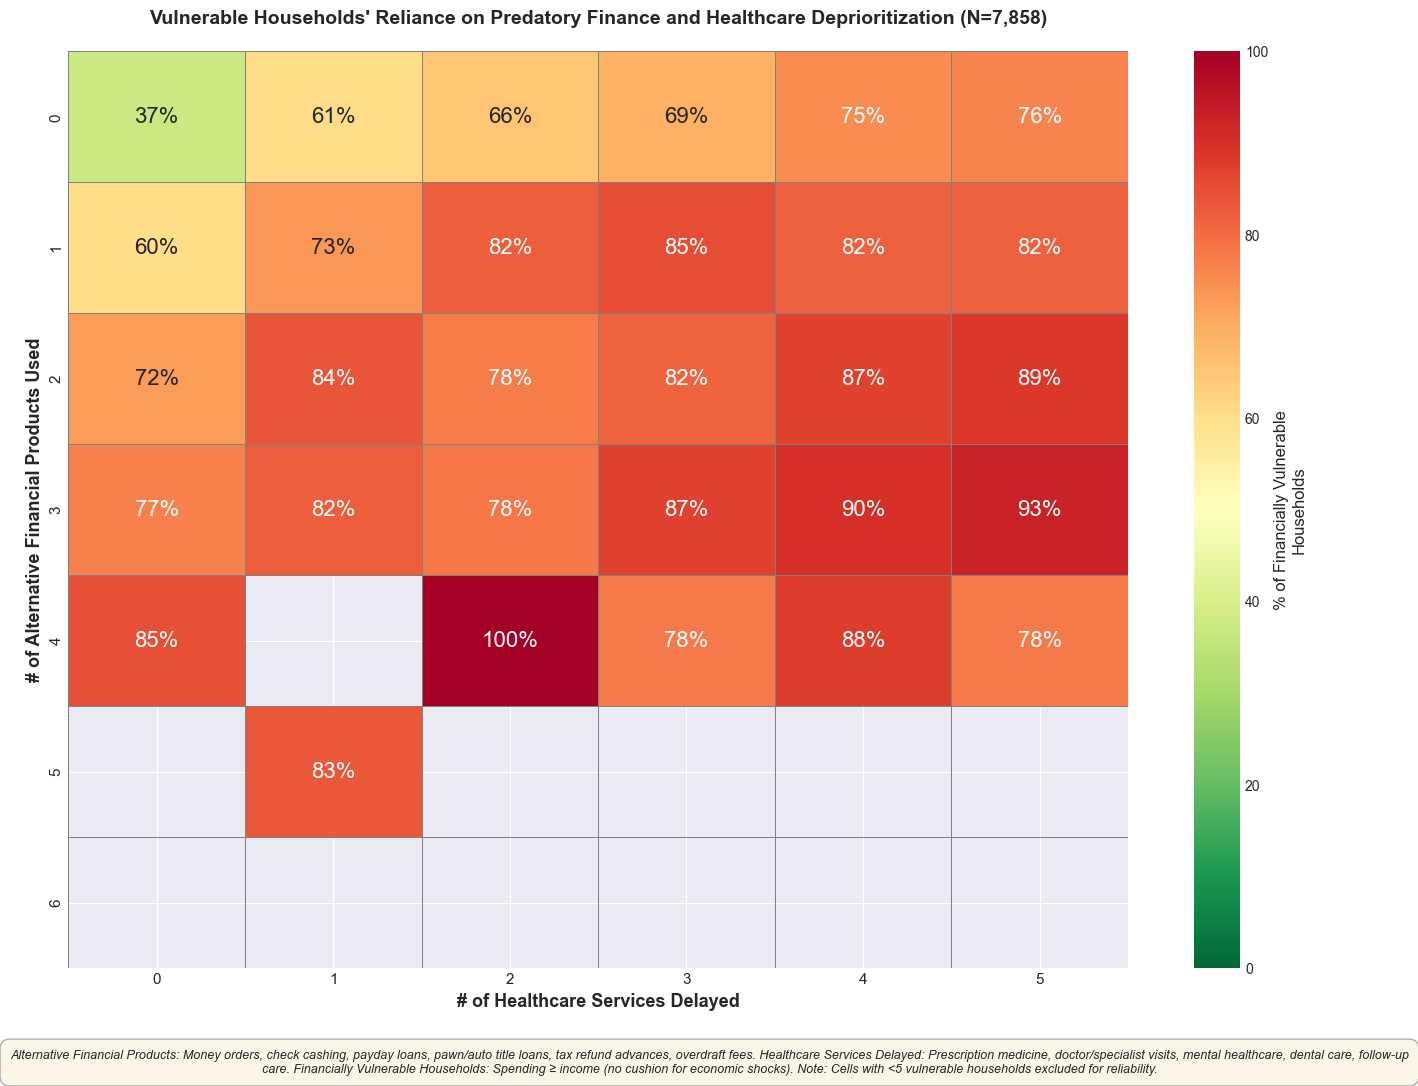

In [38]:
# Create heatmap
fig, ax = plt.subplots(figsize=(14, 11))

# Create custom annotations showing % vulnerable
annotations = np.empty_like(vulnerable_pct_matrix, dtype=object)
for i in range(vulnerable_pct_matrix.shape[0]):
    for j in range(vulnerable_pct_matrix.shape[1]):
        if count_matrix[i, j] > 0:
            pct = vulnerable_pct_matrix[i, j]
            n_vuln = int(vulnerable_count_matrix[i, j])
            
            # Only show if we have enough vulnerable households for reliability
            if n_vuln >= 5:
                annotations[i, j] = f'{pct:.0f}%'
            else:
                annotations[i, j] = f'({n_vuln} vuln)\ntoo few'
        else:
            annotations[i, j] = ''

# Create mask: hide cells with < 5 vulnerable households OR empty cells
mask = (vulnerable_count_matrix < 5) | (count_matrix == 0)

# Create heatmap with color intensity = % vulnerable
sns.heatmap(vulnerable_pct_matrix, 
            annot=annotations, 
            fmt='',  # Use custom annotations
            cmap='RdYlGn_r',  # Red = high vulnerability, Green = low vulnerability
            cbar_kws={'label': '% of Financially Vulnerable\nHouseholds'},
            vmin=0, vmax=100,
            linewidths=0.5,
            linecolor='gray',
            ax=ax,
            annot_kws={'fontsize': 16},  # Larger font for readability
            mask=mask)  # Mask cells with too few vulnerable households

# Labels
ax.set_xlabel('# of Healthcare Services Delayed', fontweight='bold', fontsize=13)
ax.set_ylabel('# of Alternative Financial Products Used', fontweight='bold', fontsize=13)

# Calculate total N for title
total_n = len(df)
ax.set_title(f"Vulnerable Households' Reliance on Predatory Finance and Healthcare Deprioritization (N={total_n:,})",
            fontweight='bold', fontsize=14, pad=20)

# Fix tick labels
ax.set_xticklabels(list(e1_range), fontsize=11)
ax.set_yticklabels(list(bk2_range), fontsize=11)

# Add footnote below chart
footnote_text = (
    "Alternative Financial Products: Money orders, check cashing, payday loans, pawn/auto title loans, tax refund advances, overdraft fees. "
    "Healthcare Services Delayed: Prescription medicine, doctor/specialist visits, mental healthcare, dental care, follow-up care. "
    "Financially Vulnerable Households: Spending ≥ income (no cushion for economic shocks). "
    "Note: Cells with <5 vulnerable households excluded for reliability."
)

fig.text(0.5, 0.02, footnote_text, ha='center', fontsize=9, style='italic', wrap=True,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.3))

plt.tight_layout(rect=[0, 0.06, 1, 1])  # Leave space for footnote
plt.show()


In [37]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Clustering patterns reveal the comorbidity mechanism:")
print("")
print("Financially Vulnerable = Spending ≥ Income (no cushion for shocks)")
print(f"Filter applied: Only showing cells with ≥5 vulnerable households for statistical reliability")
print("")

# Identify high-risk cells (only those meeting the filter)
print("DIAGONAL ESCALATION PATTERN:")
print("As you move diagonally (↗) toward high BK2 + high E1, vulnerability intensifies:")
print("")

# Show some key cells (only if they meet the filter)
key_cells = [
    (0, 0, "Origin: No services, no barriers"),
    (0, 3, "Healthcare barriers only (moderate)"),
    (3, 0, "Predatory finance only (moderate)"),
    (3, 3, "High comorbidity zone"),
]

for bk2, e1, label in key_cells:
    if vulnerable_count_matrix[bk2, e1] >= 5:
        pct = vulnerable_pct_matrix[bk2, e1]
        count = int(count_matrix[bk2, e1])
        n_vuln = int(vulnerable_count_matrix[bk2, e1])
        print(f"{label} (BK2={bk2}, E1={e1}):")
        print(f"  {pct:.0f}% vulnerable | n={count} ({n_vuln} vulnerable)")
    else:
        print(f"{label} (BK2={bk2}, E1={e1}): [filtered - too few vulnerable households]")
print()

# Calculate corner statistics (only using reliable cells)
if vulnerable_count_matrix[0, 0] >= 5:
    origin = vulnerable_pct_matrix[0, 0]
    
    # Find high-comorbidity cells with reliable data
    high_cells = [(i, j) for i in range(3, 7) for j in range(3, 6) 
                  if vulnerable_count_matrix[i, j] >= 5]
    
    if high_cells:
        high_both = np.nanmean([vulnerable_pct_matrix[i, j] for i, j in high_cells])
        print(f"Vulnerability rate at origin (0,0): {origin:.0f}%")
        print(f"Average vulnerability in high-comorbidity zone (BK2≥3, E1≥3): {high_both:.0f}%")
        print(f"Multiplier: {high_both/origin:.1f}x")
        print(f"  (Based on {len(high_cells)} reliable cells in high-comorbidity zone)")
    else:
        print("Note: High-comorbidity zone cells have too few vulnerable households for reliable comparison")

print()
print("THE CLUSTERING MECHANISM:")
print("Financial vulnerability creates BOTH problems simultaneously:")
print("• Need money → Turn to predatory finance (BK2 ↑)")
print("• Can't afford care → Skip healthcare (E1 ↑)")
print("• This isn't coincidence - it's the same underlying crisis manifesting in two ways.")
print()
print(f"Data quality: {np.sum(vulnerable_count_matrix >= 5):.0f} of {np.sum(count_matrix > 0):.0f} cells meet reliability threshold")


=== KEY INSIGHTS ===

Clustering patterns reveal the comorbidity mechanism:

Financially Vulnerable = Spending ≥ Income (no cushion for shocks)
Filter applied: Only showing cells with ≥5 vulnerable households for statistical reliability

DIAGONAL ESCALATION PATTERN:
As you move diagonally (↗) toward high BK2 + high E1, vulnerability intensifies:

Origin: No services, no barriers (BK2=0, E1=0):
  37% vulnerable | n=4678 (1738 vulnerable)
Healthcare barriers only (moderate) (BK2=0, E1=3):
  69% vulnerable | n=238 (165 vulnerable)
Predatory finance only (moderate) (BK2=3, E1=0):
  77% vulnerable | n=52 (40 vulnerable)
High comorbidity zone (BK2=3, E1=3):
  87% vulnerable | n=23 (20 vulnerable)

Vulnerability rate at origin (0,0): 37%
Average vulnerability in high-comorbidity zone (BK2≥3, E1≥3): 85%
Multiplier: 2.3x
  (Based on 6 reliable cells in high-comorbidity zone)

THE CLUSTERING MECHANISM:
Financial vulnerability creates BOTH problems simultaneously:
• Need money → Turn to predator

---
# Analysis Complete

All 8 charts have been created.

## Chart Summary:

1. **Industry/Income Stress Heatmap** - Shows who's most vulnerable
2. **Industry → Volatility → Stress Sankey** - Shows the pathway mechanism  
3. **Inflation Response Escalation Sankey** - Shows escalation from individual coping to crisis mode (3+ actions)
4. **Alternative Finance Slope Graph** - Shows 3-7x escalation in predatory services
5. **Healthcare Access Diverging Bars** - Shows 3-5x gaps in healthcare access
6. **Intergenerational Sankey** - Shows parents' education → current outcomes
7. **The Triple Threat Sankey** - Shows predatory finance + healthcare deprioritization comorbidity